# Beginner tutorial: explore CESM output — `lcz_lndcam_lcz`

This notebook explores the real CESM archive: its atmospheric and land/urban history files, temporal coverage, variables, statistics, maps, and a first time series. Run it from top to bottom. The archive is large, so code reads one file or variable at a time.

## 1. Install packages if needed

Run the import cell first. If it fails, remove the `#` below and run the installation line. On ARCHER2, select a Python environment with NetCDF support.

In [2]:
# Install only if the imports in the next cell fail.
# Installs into the Python environment used by this notebook kernel.
# %pip install numpy xarray netCDF4 pandas matplotlib
# A CESM-compatible ARCHER2 environment may also need: !module load cray-python cray-netcdf-hdf5parallel

## 2. Import libraries and locate the archive

This code sets paths once so that later cells work from the actual case archive.

In [1]:
# Import path/file, regular-expression, numeric, table, NetCDF, and plotting tools.
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (11, 5)

# Define the case archive and its key output directories.
CASE = 'lcz_lndcam_lcz'
ROOT = Path('/work/n02/n02/yue_li/cesm/archive')
ARCHIVE = ROOT / CASE
ATM, LND, REST = ARCHIVE/'atm'/'hist', ARCHIVE/'lnd'/'hist', ARCHIVE/'rest'
print('Archive:', ARCHIVE, '\nExists:', ARCHIVE.is_dir())

Archive: /work/n02/n02/yue_li/cesm/archive/lcz_lndcam_lcz 
Exists: True


## 3. Classify output types, count files, and verify resolution

`cam` files are atmospheric history; `clm2` files are land/urban history. CAM `h0a`, `h0i`, `h1a`, and `h1i` are its history streams. CLM `h0` and `h1` are land history streams. The code extracts this information from every actual filename and confirms whether each stream is monthly or annual.

In [2]:
# get the list of atmospheric and land model output files, sorted by name
atm_files, lnd_files = sorted(ATM.glob('*.nc')), sorted(LND.glob('*.nc'))
len(atm_files), len(lnd_files)

(1470, 60)

In [3]:
# Define a function to extract the model type and stream label from a CESM output file name.
def classify(f):
    cam = re.search(r'\.cam\.([^.]+)\.', f.name); clm = re.search(r'\.clm2\.([^.]+)\.', f.name)
    if cam: return 'Atmosphere', 'CAM ' + cam.group(1)
    if clm: return 'Land', 'CLM ' + clm.group(1)
    return 'Other', 'Other'

In [4]:
# Define a function to extract the date string from a CESM output file name.
def file_date_str(f):
    name = f.name
    date_str = name.rsplit('.', 2)[-2]
    return date_str

In [5]:
# Print the file name, date string, and number of hyphens in the date string for each atmospheric and land model output file.
# for f in atm_files + lnd_files:
#     print(f, file_date(f), file_date(f).count('-'))

# Print the unique date strings and the unique counts of hyphens in the date strings for all atmospheric and land model output files.
dates = sorted(set(file_date_str(f) for f in atm_files + lnd_files))
date_types = sorted(set(file_date_str(f).count('-') for f in atm_files + lnd_files))
for date in dates:
    print(date)
for date_type in date_types:
    print(date_type)

2015-01
2015-02
2015-02-01-00000
2015-03
2015-04
2015-05
2015-06
2015-07
2015-08
2015-09
2015-10
2015-11
2015-12
2016-01
2016-01-01-00000
2016-02
2016-02-01-00000
2016-03
2016-04
2016-05
2016-06
2016-07
2016-08
2016-09
2016-10
2016-11
2016-12
2017-01
2017-01-01-00000
2017-02
2017-02-01-00000
2017-03
2017-04
2017-05
2017-06
2017-07
2017-08
2017-09
2017-10
2017-11
2017-12
2018-01
2018-01-01-00000
2018-02
2018-02-01-00000
2018-03
2018-04
2018-05
2018-06
2018-07
2018-08
2018-09
2018-10
2018-11
2018-12
2019-01
2019-01-01-00000
2019-02
2019-02-01-00000
2019-03
2019-04
2019-05
2019-06
2019-07
2019-08
2019-09
2019-10
2019-11
2019-12
2020-01
2020-01-01-00000
2020-02
2020-02-01-00000
2020-03
2020-04
2020-05
2020-06
2020-07
2020-08
2020-09
2020-10
2020-11
2020-12
2021-01
2021-01-01-00000
2021-02
2021-02-01-00000
2021-03
2021-04
2021-05
2021-06
2021-07
2021-08
2021-09
2021-10
2021-11
2021-12
2022-01
2022-01-01-00000
2022-02
2022-02-01-00000
2022-03
2022-04
2022-05
2022-06
2022-07
2022-08
2022-09
2

In [6]:
# Define a function to convert the date string from a CESM output file name into a pandas datetime object.
def file_date(f):
    date_str = file_date_str(f)

    if date_str.count('-') == 1:
        return pd.to_datetime(date_str, format='%Y-%m')

    if date_str.count('-') == 3:
        return pd.to_datetime(date_str[:10], format='%Y-%m-%d')

    return pd.NaT

In [7]:
# Build an inventory with file type, storage, examples, and date.
rows = []
for f in atm_files + lnd_files:
    row = {
        'type': classify(f)[0],
        'stream': classify(f)[1],
        'file': f.name,
        'GiB': f.stat().st_size / 1024**3,
        'date': file_date(f)
    }
    rows.append(row)
files = pd.DataFrame(rows)
files

,type,stream,file,GiB,date
0,Atmosphere,CAM h0a,lcz_lndcam_lcz.cam.h0a.2015-01.nc,0.907882,2015-01-01
1,Atmosphere,CAM h0a,lcz_lndcam_lcz.cam.h0a.2015-02.nc,0.907882,2015-02-01
2,Atmosphere,CAM h0a,lcz_lndcam_lcz.cam.h0a.2015-03.nc,0.907882,2015-03-01
3,Atmosphere,CAM h0a,lcz_lndcam_lcz.cam.h0a.2015-04.nc,0.907882,2015-04-01
4,Atmosphere,CAM h0a,lcz_lndcam_lcz.cam.h0a.2015-05.nc,0.907882,2015-05-01
...,...,...,...,...,...
1525,Land,CLM h1,lcz_lndcam_lcz.clm2.h1.2040-02-01-00000.nc,0.162333,2040-02-01
1526,Land,CLM h1,lcz_lndcam_lcz.clm2.h1.2041-02-01-00000.nc,0.162333,2041-02-01
1527,Land,CLM h1,lcz_lndcam_lcz.clm2.h1.2042-02-01-00000.nc,0.162333,2042-02-01
1528,Land,CLM h1,lcz_lndcam_lcz.clm2.h1.2043-02-01-00000.nc,0.162333,2043-02-01


In [8]:
# Build a summary of the inventory for each type and stream.
summary = files.groupby(['type','stream']).agg(
    file_number=('file','count'),
    average_GiB=('GiB','mean'),
    start_date=('date','min'),
    end_date=('date','max'),
    example=('file','first')
)
summary = summary.reset_index()
summary

,type,stream,file_number,average_GiB,start_date,end_date,example
0,Atmosphere,CAM h0a,360,0.907882,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h0a.2015-01.nc
1,Atmosphere,CAM h0i,360,0.000216,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h0i.2015-01.nc
2,Atmosphere,CAM h1a,360,0.082412,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h1a.2015-01.nc
3,Atmosphere,CAM h1i,360,0.000010,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h1i.2015-01.nc
4,Atmosphere,CAM i,30,0.488159,2016-01-01,2045-01-01,lcz_lndcam_lcz.cam.i.2016-01-01-00000.nc
5,Land,CLM h0,30,0.187673,2015-02-01,2044-02-01,lcz_lndcam_lcz.clm2.h0.2015-02-01-00000.nc
6,Land,CLM h1,30,0.162333,2015-02-01,2044-02-01,lcz_lndcam_lcz.clm2.h1.2015-02-01-00000.nc


In [9]:
# Define a function to read time information from a CESM output file and return it as a dictionary.
def read_time_info(f):

    time_details = {}
    with xr.open_dataset(f, decode_times=True) as ds:
        bounds_name = ds['time'].attrs.get('bounds', 'time_bounds')
        time_details[(file_type, stream)] = {
            'file': f.name,
            'dimensions': dict(ds.sizes),
            'frequency': ds.attrs.get('time_period_freq'),
            'time': ds['time'].to_dataframe(),
            'time_bounds': ds[bounds_name].to_dataframe(),
        }
    return time_details

In [34]:
# Define a function to summarize the time information from a CESM output file and return it as a pandas DataFrame.
def summary_time_info(time_details):

    time_summary = []
    for (file_type, stream), details in time_info.items():
        
        time = details['time'].index
        time_bounds = details['time_bounds']
        
        time_summary.append({
            'type': file_type,
            'stream': stream,
            'example': details['file'],
            'time_sampling': details['frequency'],
            'records_per_file': len(time),
            'start_time': time.min(),
            'end_time': time.max(),
            'bound0': time_bounds.loc[time.min()].time_bounds.tolist(),
            'bound1': time_bounds.loc[time.max()].time_bounds.tolist(),
        })

    time_summary = pd.DataFrame(time_summary)
    return time_summary

In [35]:
# Read the time information from each representative file in the file summary df and summarize it.
all_time_info = []

for _, row in summary.iterrows():
    file_type = row['type']
    stream = row['stream']
    f_name = row['example']

    if file_type == 'Atmosphere':
        f = ATM / f_name
    elif file_type == 'Land':
        f = LND / f_name

    time_info = read_time_info(f)
    time_info_summary = summary_time_info(time_info)
    all_time_info.append(time_info_summary)

all_time_df = pd.concat(all_time_info)
all_time_df

,type,stream,example,time_sampling,records_per_file,start_time,end_time,bound0,bound1
0,Atmosphere,CAM h0a,lcz_lndcam_lcz.cam.h0a.2015-01.nc,month_1,1,2015-01-16 12:00:00,2015-01-16 12:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]"
0,Atmosphere,CAM h0i,lcz_lndcam_lcz.cam.h0i.2015-01.nc,month_1,1,2015-02-01 00:00:00,2015-02-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]"
0,Atmosphere,CAM h1a,lcz_lndcam_lcz.cam.h1a.2015-01.nc,month_1,1,2015-01-16 12:00:00,2015-01-16 12:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]"
0,Atmosphere,CAM h1i,lcz_lndcam_lcz.cam.h1i.2015-01.nc,month_1,1,2015-02-01 00:00:00,2015-02-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]"
0,Atmosphere,CAM i,lcz_lndcam_lcz.cam.i.2016-01-01-00000.nc,day_1,1,2016-01-01 00:00:00,2016-01-01 00:00:00,"[2016-01-01 00:00:00, 2016-01-01 00:00:00]","[2016-01-01 00:00:00, 2016-01-01 00:00:00]"
0,Land,CLM h0,lcz_lndcam_lcz.clm2.h0.2015-02-01-00000.nc,month_1,12,2015-02-01 00:00:00,2016-01-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-12-01 00:00:00, 2016-01-01 00:00:00]"
0,Land,CLM h1,lcz_lndcam_lcz.clm2.h1.2015-02-01-00000.nc,month_1,12,2015-02-01 00:00:00,2016-01-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-12-01 00:00:00, 2016-01-01 00:00:00]"


In [40]:
file_summary = pd.merge(summary, all_time_df, how="left", on=["type", "stream", "example"])
file_summary

,type,stream,file_number,average_GiB,start_date,end_date,example,time_sampling,records_per_file,start_time,end_time,bound0,bound1
0,Atmosphere,CAM h0a,360,0.907882,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h0a.2015-01.nc,month_1,1,2015-01-16 12:00:00,2015-01-16 12:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]"
1,Atmosphere,CAM h0i,360,0.000216,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h0i.2015-01.nc,month_1,1,2015-02-01 00:00:00,2015-02-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]"
2,Atmosphere,CAM h1a,360,0.082412,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h1a.2015-01.nc,month_1,1,2015-01-16 12:00:00,2015-01-16 12:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]"
3,Atmosphere,CAM h1i,360,0.000010,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h1i.2015-01.nc,month_1,1,2015-02-01 00:00:00,2015-02-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]"
4,Atmosphere,CAM i,30,0.488159,2016-01-01,2045-01-01,lcz_lndcam_lcz.cam.i.2016-01-01-00000.nc,day_1,1,2016-01-01 00:00:00,2016-01-01 00:00:00,"[2016-01-01 00:00:00, 2016-01-01 00:00:00]","[2016-01-01 00:00:00, 2016-01-01 00:00:00]"
5,Land,CLM h0,30,0.187673,2015-02-01,2044-02-01,lcz_lndcam_lcz.clm2.h0.2015-02-01-00000.nc,month_1,12,2015-02-01 00:00:00,2016-01-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-12-01 00:00:00, 2016-01-01 00:00:00]"
6,Land,CLM h1,30,0.162333,2015-02-01,2044-02-01,lcz_lndcam_lcz.clm2.h1.2015-02-01-00000.nc,month_1,12,2015-02-01 00:00:00,2016-01-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-12-01 00:00:00, 2016-01-01 00:00:00]"


## 4. Open actual files and list their scientific information

A NetCDF file stores dimensions, coordinates, data variables, and metadata. The catalogue below lists every variable, its dimensions, units, and description (`long_name`) without loading all data into memory. The search finds beginner-relevant atmosphere and urban-climate fields.

In [ ]:
# Create a human-readable metadata table from all data variables in a dataset.
def catalogue(ds):
    return pd.DataFrame([
        {
            'variable': name,
            'dimensions': ', '.join(da.dims),
            'units': da.attrs.get('units', '(not specified)'),
            'meaning': da.attrs.get(
                'long_name',
                da.attrs.get('standard_name', '(not specified)')
            ),
        }
        for name, da in ds.data_vars.items()
    ]).sort_values('variable').reset_index(drop=True)

In [29]:
# Display the dataset and its data variables for each representative file in the file summary df.
representatives = summary[['type','example']]
for index, row in representatives.iterrows():
    file_type = row['type']
    filename = row['example']

    if file_type == 'Atmosphere':
        f = ATM / filename
    elif file_type == 'Land':
        f = LND / filename
    dataset = xr.open_dataset(f) 
    data_variables = catalogue(dataset)
    print(filename); display(dataset); display(data_variables)


lcz_lndcam_lcz.cam.h0a.2015-01.nc


<xarray.Dataset> Size: 975MB
Dimensions:           (lat: 192, lon: 288, lev: 32, ilev: 33, time: 1, nbnd: 2)
Coordinates:
  * lat               (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon               (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev               (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev              (ilev) float64 264B 2.255 5.032 10.16 ... 985.1 1e+03
  * time              (time) object 8B 2015-01-16 12:00:00
Dimensions without coordinates: nbnd
Data variables: (12/348)
    gw                (lat) float64 2kB ...
    hyam              (lev) float64 256B ...
    hybm              (lev) float64 256B ...
    P0                float64 8B ...
    hyai              (ilev) float64 264B ...
    hybi              (ilev) float64 264B ...
    ...                ...
    RTP2_CLUBB        (time, ilev, lat, lon) float32 7MB ...
    THLP2_CLUBB       (time, ilev, lat, lon) float32 7MB ...
    RTPTHLP_CLUBB     (time, ilev, lat, lon) float32 7MB ...
    WPRCP_CLUBB       (time, ilev, lat, lon) float32 7MB ...
    WPTHVP_CLUBB      (time, ilev, lat, lon) float32 7MB ...
    ZM_CLUBB          (time, ilev, lat, lon) float32 7MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              lcz_lndcam_lcz
    logname:           yue_li
    host:              ln01
    initial_file:      lczspinup_lndcam_lcz_fhist.cam.i.2015-01-01-00000.nc
    topography_file:   /work/n02/n02/yue_li/cesm/cesm_inputdata/atm/cam/topo/...
    model_doi_url:     not_set
    time_period_freq:  month_1

,variable,dimensions,units,meaning
0,ADRAIN,"time, lev, lat, lon",m,Average rain effective Diameter
1,ADSNOW,"time, lev, lat, lon",m,Average snow effective Diameter
2,AEROD_v,"time, lat, lon",1,Total Aerosol Optical Depth in visible band
3,ANRAIN,"time, lev, lat, lon",m-3,Average rain number conc
4,ANSNOW,"time, lev, lat, lon",m-3,Average snow number conc
...,...,...,...,...
343,soa_c1SFWET,"time, lat, lon",kg/m2/s,soa_c1 wet deposition flux at surface
344,soa_c2,"time, lev, lat, lon",kg/kg,soa_c2 in cloud water
345,soa_c2SFWET,"time, lat, lon",kg/m2/s,soa_c2 wet deposition flux at surface
346,time_bounds,"time, nbnd",(not specified),time interval endpoints


lcz_lndcam_lcz.cam.h0i.2015-01.nc


<xarray.Dataset> Size: 228kB
Dimensions:       (lat: 192, lon: 288, lev: 32, ilev: 33, time: 1, nbnd: 2)
Coordinates:
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 8B 2015-02-01 00:00:00
Dimensions without coordinates: nbnd
Data variables: (12/26)
    gw            (lat) float64 2kB ...
    hyam          (lev) float64 256B ...
    hybm          (lev) float64 256B ...
    P0            float64 8B ...
    hyai          (ilev) float64 264B ...
    hybi          (ilev) float64 264B ...
    ...            ...
    n2ovmr        (time) float64 8B ...
    f11vmr        (time) float64 8B ...
    f12vmr        (time) float64 8B ...
    sol_tsi       (time) float64 8B ...
    nsteph        (time) int32 4B ...
    PHIS          (time, lat, lon) float32 221kB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              lcz_lndcam_lcz
    logname:           yue_li
    host:              ln01
    initial_file:      lczspinup_lndcam_lcz_fhist.cam.i.2015-01-01-00000.nc
    topography_file:   /work/n02/n02/yue_li/cesm/cesm_inputdata/atm/cam/topo/...
    model_doi_url:     not_set
    time_period_freq:  month_1

...

<xarray.Dataset> Size: 239MB
Dimensions:        (levgrnd: 25, levsoi: 20, levlak: 10, levdcmp: 1, time: 12,
                    hist_interval: 2, lon: 288, lat: 192)
Coordinates:
  * levgrnd        (levgrnd) float32 100B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * levsoi         (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.95 6.94 8.03
  * levlak         (levlak) float32 40B 0.05 0.6 2.1 4.6 ... 25.6 34.33 44.78
  * levdcmp        (levdcmp) float32 4B 1.0
  * time           (time) object 96B 2015-02-01 00:00:00 ... 2016-01-01 00:00:00
  * lon            (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lat            (lat) float32 768B -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
Dimensions without coordinates: hist_interval
Data variables: (12/94)
    mcdate         (time) int32 48B ...
    mcsec          (time) int32 48B ...
    mdcur          (time) int32 48B ...
    mscur          (time) int32 48B ...
    nstep          (time) int32 48B ...
    time_bounds    (time, hist_interval) object 192B ...
    ...             ...
    VENTILATION    (time, lat, lon) float32 3MB ...
    WASTEHEAT      (time, lat, lon) float32 3MB ...
    WBT            (time, lat, lon) float32 3MB ...
    WBT_R          (time, lat, lon) float32 3MB ...
    WBT_U          (time, lat, lon) float32 3MB ...
    WIND           (time, lat, lon) float32 3MB ...
Attributes: (12/106)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 08/26/26 15:54:15
    source:                               Community Terrestrial Systems Model
    hostname:                             archer2
    ...                                   ...
    cft_irrigated_switchgrass:            60
    cft_tropical_corn:                    61
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     month_1

,variable,dimensions,units,meaning
0,APPAR_TEMP,"time, lat, lon",C,2 m apparent temperature
1,APPAR_TEMP_R,"time, lat, lon",C,Rural 2 m apparent temperature
2,APPAR_TEMP_U,"time, lat, lon",C,Urban 2 m apparent temperature
3,BSW,"levgrnd, lat, lon",unitless,slope of soil water retention curve
4,DISCOI,"time, lat, lon",C,2 m Discomfort Index
...,...,...,...,...
89,mscur,time,(not specified),current seconds of current day
90,nbedrock,"lat, lon",(not specified),index of shallowest bedrock layer
91,nstep,time,(not specified),time step
92,time_bounds,"time, hist_interval",(not specified),history time interval endpoints


lcz_lndcam_lcz.clm2.h1.2015-02-01-00000.nc


<xarray.Dataset> Size: 194MB
Dimensions:             (levgrnd: 25, levsoi: 20, levlak: 10, levdcmp: 1,
                         time: 12, hist_interval: 2, lon: 288, lat: 192,
                         gridcell: 21013, landunit: 77834, column: 238689,
                         pft: 294759)
Coordinates:
  * levgrnd             (levgrnd) float32 100B 0.01 0.04 0.09 ... 28.87 42.0
  * levsoi              (levsoi) float32 80B 0.01 0.04 0.09 ... 5.95 6.94 8.03
  * levlak              (levlak) float32 40B 0.05 0.6 2.1 ... 25.6 34.33 44.78
  * levdcmp             (levdcmp) float32 4B 1.0
  * time                (time) object 96B 2015-02-01 00:00:00 ... 2016-01-01 ...
  * lon                 (lon) float32 1kB 0.0 1.25 2.5 ... 356.2 357.5 358.8
  * lat                 (lat) float32 768B -90.0 -89.06 -88.12 ... 89.06 90.0
Dimensions without coordinates: hist_interval, gridcell, landunit, column, pft
Data variables: (12/85)
    mcdate              (time) int32 48B ...
    mcsec               (time) int32 48B ...
    mdcur               (time) int32 48B ...
    mscur               (time) int32 48B ...
    nstep               (time) int32 48B ...
    time_bounds         (time, hist_interval) object 192B ...
    ...                  ...
    U10                 (time, landunit) float32 4MB ...
    URBAN_AC            (time, landunit) float32 4MB ...
    URBAN_HEAT          (time, landunit) float32 4MB ...
    VENTILATION         (time, landunit) float32 4MB ...
    WASTEHEAT           (time, landunit) float32 4MB ...
    WBT                 (time, landunit) float32 4MB ...
Attributes: (12/108)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 08/26/26 15:54:16
    source:                               Community Terrestrial Systems Model
    hostname:                             archer2
    ...                                   ...
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     month_1
    Time_constant_3Dvars_filename:        ./lcz_lndcam_lcz.clm2.h0.2015-02-01...
    Time_constant_3Dvars:                 ZSOI:DZSOI:WATSAT:SUCSAT:BSW:HKSAT:...

,variable,dimensions,units,meaning
0,APPAR_TEMP,"time, landunit",C,2 m apparent temperature
1,DISCOI,"time, landunit",C,2 m Discomfort Index
2,DISCOIS,"time, landunit",C,2 m Stull Discomfort Index
3,EFLXBUILD,"time, landunit",W/m^2,building heat flux from change in interior bui...
4,EFLX_LH_TOT,"time, landunit",W/m^2,total latent heat flux [+ to atm]
...,...,...,...,...
80,pfts1d_wtcol,pft,(not specified),pft weight relative to corresponding column
81,pfts1d_wtgcell,pft,(not specified),pft weight relative to corresponding gridcell
82,pfts1d_wtlunit,pft,(not specified),pft weight relative to corresponding landunit
83,time_bounds,"time, hist_interval",(not specified),history time interval endpoints


In [27]:
# # Search both variable name and description for commonly useful topics.
# topics = 'temperature|precip|urban|building|heat|humid|wind|radiation'
# for label, table in [('Atmosphere',atm_catalogue), ('Land/urban',lnd_catalogue)]:
#     text = table.variable.fillna('') + ' ' + table.meaning.fillna('')
#     print(label + ' fields related to selected topics:'); display(table[text.str.contains(topics,case=False,regex=True)])

In [44]:
# Collect additional information from the representative file of each stream.

additional_summary = []

for _, row in file_summary.iterrows():

    file_type = row['type']
    stream = row['stream']
    filename = row['example']


    # Build the full path from the file type and representative filename.
    if file_type == 'Atmosphere':
        f = ATM / filename
    elif file_type == 'Land':
        f = LND / filename

    # Open the representative file and inspect its structure.
    with xr.open_dataset(f, decode_times=True) as ds:

        # Number of data variables in the representative file.
        variables = len(ds.data_vars)

        # Dimensions and their sizes.
        dimensions = ' × '.join(
            f'{name}={size}' for name, size in ds.sizes.items()
        )

        # Describe how the spatial data are represented.
        if 'land' in ds.sizes:
            spatial_form = '1D LAND vector; spatial mapping variables included'

        elif 'lat' in ds.sizes and 'lon' in ds.sizes:
            spatial_form = (
                f'lat × lon grid: {ds.sizes["lat"]} × {ds.sizes["lon"]}'
            )

        else:
            spatial_form = 'See dimensions'

        # Number of time records in this representative file.
        total_time_records = row['file_number']*row['records_per_file']

    additional_summary.append({
        'stream': stream,
        'data variables in representative file': variables,
        'spatial representation': spatial_form,
        'dimensions': dimensions,
        'total time records': total_time_records,
    })

additional_summary = pd.DataFrame(additional_summary)

display(additional_summary)

,stream,data variables in representative file,spatial representation,dimensions,total time records
0,CAM h0a,348,lat × lon grid: 192 × 288,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...,360
1,CAM h0i,26,lat × lon grid: 192 × 288,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...,360
2,CAM h1a,43,lat × lon grid: 192 × 288,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...,360
3,CAM h1i,25,lat × lon grid: 192 × 288,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...,360
4,CAM i,58,lat × lon grid: 192 × 288,slat=191 × lon=288 × lat=192 × slon=288 × lev=...,30
5,CLM h0,94,lat × lon grid: 192 × 288,levgrnd=25 × levsoi=20 × levlak=10 × levdcmp=1...,360
6,CLM h1,85,lat × lon grid: 192 × 288,levgrnd=25 × levsoi=20 × levlak=10 × levdcmp=1...,360


In [45]:
all_summary = pd.merge(file_summary, additional_summary, how="left", on=["stream"])
list(all_summary)
all_summary
# all_summary = all_summary[['type', 'stream', 'files', 'total_GiB', 'first', 'last', 'example']]

,type,stream,file_number,average_GiB,start_date,end_date,example,time_sampling,records_per_file,start_time,end_time,bound0,bound1,data variables in representative file,spatial representation,dimensions,total time records
0,Atmosphere,CAM h0a,360,0.907882,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h0a.2015-01.nc,month_1,1,2015-01-16 12:00:00,2015-01-16 12:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]",348,lat × lon grid: 192 × 288,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...,360
1,Atmosphere,CAM h0i,360,0.000216,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h0i.2015-01.nc,month_1,1,2015-02-01 00:00:00,2015-02-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]",26,lat × lon grid: 192 × 288,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...,360
2,Atmosphere,CAM h1a,360,0.082412,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h1a.2015-01.nc,month_1,1,2015-01-16 12:00:00,2015-01-16 12:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]",43,lat × lon grid: 192 × 288,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...,360
3,Atmosphere,CAM h1i,360,0.000010,2015-01-01,2044-12-01,lcz_lndcam_lcz.cam.h1i.2015-01.nc,month_1,1,2015-02-01 00:00:00,2015-02-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-01-01 00:00:00, 2015-02-01 00:00:00]",25,lat × lon grid: 192 × 288,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...,360
4,Atmosphere,CAM i,30,0.488159,2016-01-01,2045-01-01,lcz_lndcam_lcz.cam.i.2016-01-01-00000.nc,day_1,1,2016-01-01 00:00:00,2016-01-01 00:00:00,"[2016-01-01 00:00:00, 2016-01-01 00:00:00]","[2016-01-01 00:00:00, 2016-01-01 00:00:00]",58,lat × lon grid: 192 × 288,slat=191 × lon=288 × lat=192 × slon=288 × lev=...,30
5,Land,CLM h0,30,0.187673,2015-02-01,2044-02-01,lcz_lndcam_lcz.clm2.h0.2015-02-01-00000.nc,month_1,12,2015-02-01 00:00:00,2016-01-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-12-01 00:00:00, 2016-01-01 00:00:00]",94,lat × lon grid: 192 × 288,levgrnd=25 × levsoi=20 × levlak=10 × levdcmp=1...,360
6,Land,CLM h1,30,0.162333,2015-02-01,2044-02-01,lcz_lndcam_lcz.clm2.h1.2015-02-01-00000.nc,month_1,12,2015-02-01 00:00:00,2016-01-01 00:00:00,"[2015-01-01 00:00:00, 2015-02-01 00:00:00]","[2015-12-01 00:00:00, 2016-01-01 00:00:00]",85,lat × lon grid: 192 × 288,levgrnd=25 × levsoi=20 × levlak=10 × levdcmp=1...,360


In [42]:
# All scientific history streams in this case.
stream_patterns = {
    'CAM h0a': (atm_files, '.cam.h0a.'),
    'CAM h0i': (atm_files, '.cam.h0i.'),
    'CAM h1a': (atm_files, '.cam.h1a.'),
    'CAM h1i': (atm_files, '.cam.h1i.'),
    'CAM i':   (atm_files, '.cam.i.'),
    'CLM h0':  (lnd_files, '.clm2.h0.'),
    'CLM h1':  (lnd_files, '.clm2.h1.'),
}

def catalogue(stream, ds):
    """Return every data variable and its descriptive metadata."""
    return pd.DataFrame([
        {
            'stream': stream,
            'variable': name,
            'dimensions': ' × '.join(da.dims) or 'scalar',
            'units': da.attrs.get('units', '(not specified)'),
            'meaning': da.attrs.get(
                'long_name',
                da.attrs.get('standard_name', '(not specified)')
            ),
            'cell_methods': da.attrs.get('cell_methods', ''),
        }
        for name, da in ds.data_vars.items()
    ])

def format_time(value):
    return value.strftime('%Y-%m-%d') if hasattr(value, 'strftime') else str(value)

catalogues = []
summary_rows = []

for stream, (all_files, pattern) in stream_patterns.items():
    paths = [f for f in all_files if pattern in f.name]
    representative = paths[0]

    # Read metadata from one representative file.
    with xr.open_dataset(representative, decode_times=True) as ds:
        catalogues.append(catalogue(stream, ds))

        dimensions = ' × '.join(
            f'{name}={size}' for name, size in ds.sizes.items()
        )

        if 'land' in ds.sizes:
            spatial_form = '1D LAND vector; spatial mapping variables included'
        elif 'lat' in ds.sizes and 'lon' in ds.sizes:
            spatial_form = (
                f'lat × lon grid: {ds.sizes["lat"]} × {ds.sizes["lon"]} '
                '(nominal f09: 0.9° × 1.25°)'
            )
        else:
            spatial_form = 'See dimensions'

        frequency = ds.attrs.get('time_period_freq', 'not specified')
        variables_per_file = len(ds.data_vars)

    # Read only time coordinates from every file to obtain real coverage.
    all_times = []
    records_per_file = []

    for path in paths:
        with xr.open_dataset(path, decode_times=True) as ds:
            all_times.extend(ds['time'].values.tolist())
            records_per_file.append(ds.sizes.get('time', 0))

    summary_rows.append({
        'stream': stream,
        'files': len(paths),
        'data variables in representative file': variables_per_file,
        'time sampling': frequency,
        'records per file': f'{min(records_per_file)}–{max(records_per_file)}',
        'first time': format_time(min(all_times)),
        'last time': format_time(max(all_times)),
        'total time records': len(all_times),
        'spatial representation': spatial_form,
        'example file': representative.name,
        'dimensions': dimensions,
    })

output_summary = pd.DataFrame(summary_rows)
all_output_catalogue = (
    pd.concat(catalogues, ignore_index=True)
      .sort_values(['stream', 'variable'])
      .reset_index(drop=True)
)

print('PPT-ready output summary')
display(output_summary)

print('Complete variable catalogue: all streams, all data variables')
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 120):
    display(all_output_catalogue)

PPT-ready output summary


,stream,files,data variables in representative file,time sampling,records per file,first time,last time,total time records,spatial representation,example file,dimensions
0,CAM h0a,360,348,month_1,1–1,2015-01-16,2044-12-16,360,lat × lon grid: 192 × 288 (nominal f09: 0.9° ×...,lcz_lndcam_lcz.cam.h0a.2015-01.nc,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...
1,CAM h0i,360,26,month_1,1–1,2015-02-01,2045-01-01,360,lat × lon grid: 192 × 288 (nominal f09: 0.9° ×...,lcz_lndcam_lcz.cam.h0i.2015-01.nc,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...
2,CAM h1a,360,43,month_1,1–1,2015-01-16,2044-12-16,360,lat × lon grid: 192 × 288 (nominal f09: 0.9° ×...,lcz_lndcam_lcz.cam.h1a.2015-01.nc,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...
3,CAM h1i,360,25,month_1,1–1,2015-02-01,2045-01-01,360,lat × lon grid: 192 × 288 (nominal f09: 0.9° ×...,lcz_lndcam_lcz.cam.h1i.2015-01.nc,lat=192 × lon=288 × lev=32 × ilev=33 × time=1 ...
4,CAM i,30,58,day_1,1–1,2016-01-01,2045-01-01,30,lat × lon grid: 192 × 288 (nominal f09: 0.9° ×...,lcz_lndcam_lcz.cam.i.2016-01-01-00000.nc,slat=191 × lon=288 × lat=192 × slon=288 × lev=...
5,CLM h0,30,94,month_1,12–12,2015-02-01,2045-01-01,360,lat × lon grid: 192 × 288 (nominal f09: 0.9° ×...,lcz_lndcam_lcz.clm2.h0.2015-02-01-00000.nc,levgrnd=25 × levsoi=20 × levlak=10 × levdcmp=1...
6,CLM h1,30,85,month_1,12–12,2015-02-01,2045-01-01,360,lat × lon grid: 192 × 288 (nominal f09: 0.9° ×...,lcz_lndcam_lcz.clm2.h1.2015-02-01-00000.nc,levgrnd=25 × levsoi=20 × levlak=10 × levdcmp=1...


Complete variable catalogue: all streams, all data variables


,stream,variable,dimensions,units,meaning,cell_methods
0,CAM h0a,ADRAIN,time × lev × lat × lon,m,Average rain effective Diameter,time: mean
1,CAM h0a,ADSNOW,time × lev × lat × lon,m,Average snow effective Diameter,time: mean
2,CAM h0a,AEROD_v,time × lat × lon,1,Total Aerosol Optical Depth in visible band,time: mean
3,CAM h0a,ANRAIN,time × lev × lat × lon,m-3,Average rain number conc,time: mean
4,CAM h0a,ANSNOW,time × lev × lat × lon,m-3,Average snow number conc,time: mean
5,CAM h0a,AODDUST,time × lat × lon,(not specified),"Aerosol optical depth 550 nm from dust, day only",time: mean
6,CAM h0a,AODDUST01,time × lat × lon,(not specified),"Aerosol optical depth, day only, 550 nm mode 1 from dust",time: mean
7,CAM h0a,AODDUST03,time × lat × lon,(not specified),"Aerosol optical depth, day only, 550 nm mode 3 from dust",time: mean
8,CAM h0a,AODVIS,time × lat × lon,(not specified),Aerosol optical depth 550 nm,time: mean
9,CAM h0a,AQRAIN,time × lev × lat × lon,kg/kg,Average rain mixing ratio,time: mean


## 5. Statistical analysis and a first map

Select a variable from the catalogue. `TMQ` is a typical atmospheric field; `TBUILD` is a configured land/urban field. This code selects the first time/vertical index when necessary, reports basic statistics, and plots the resulting horizontal field. Use the displayed unit and meaning to judge whether values are physically reasonable.

meaning               internal urban building air temperature
units                                                       K
valid cells                                              7222
minimum                                            285.100006
mean                                               290.963204
median                                             290.100006
maximum                                                 300.0
standard deviation                                   5.818479
dtype: object

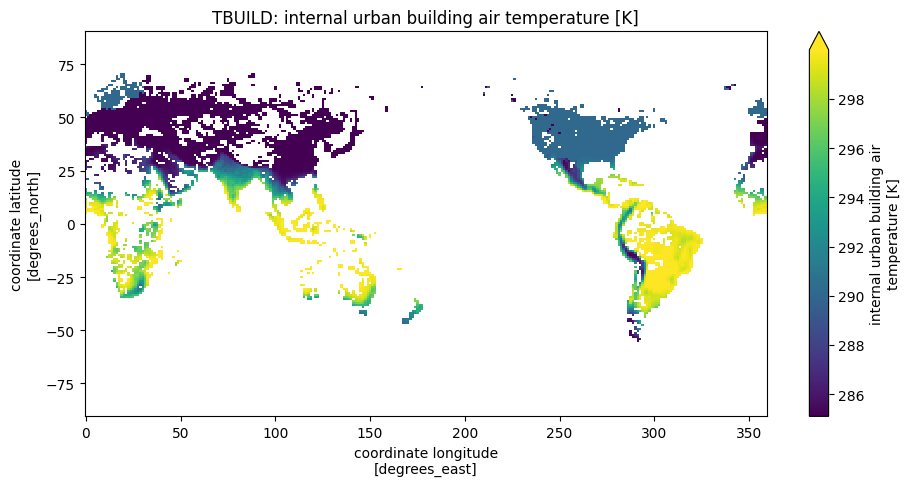

In [ ]:
# Choose which real output to analyse; edit these two values after reading the catalogue.
PLOT_DATASET, PLOT_VARIABLE = lnd_ds, 'TBUILD'

# Keep horizontal dimensions and select index zero for extra time/vertical dimensions.
def horizontal_slice(da):
    keep = {'lat','lon','lsmlat','lsmlon','gridcell'}
    return da.isel({d:0 for d in da.dims if d not in keep}, drop=True)

# Compute NaN-safe descriptive statistics on only the selected field.
def statistics(da):
    valid = np.asarray(da.load().values, dtype=float); valid = valid[np.isfinite(valid)]
    return pd.Series({'meaning':da.attrs.get('long_name',''), 'units':da.attrs.get('units',''), 'valid cells':len(valid),
      'minimum':valid.min(), 'mean':valid.mean(), 'median':np.median(valid), 'maximum':valid.max(), 'standard deviation':valid.std()})

# Check the name, calculate the statistics, and create an initial map.
if PLOT_VARIABLE not in PLOT_DATASET: raise KeyError('Select a variable that appears in the relevant catalogue.')
field = horizontal_slice(PLOT_DATASET[PLOT_VARIABLE])
display(statistics(field))
field.plot(robust=True, cmap='viridis')
plt.title(f"{PLOT_VARIABLE}: {field.attrs.get('long_name','')} [{field.attrs.get('units','')}]"); plt.show()

## 6. Plot a memory-safe preliminary time series

This reads one monthly CAM file at a time and calculates one simple spatial mean. Start with 24 files (two years); set `MAX_FILES = None` to process the full period. This is a useful diagnostic, but it is not an area-weighted global mean, so use proper grid-cell-area weighting for final scientific results.

Processed 24/24 files


,simple spatial mean
count,24.000000
mean,18.019206
std,1.326382
min,16.597561
25%,16.967943
50%,17.457689
75%,18.996952
max,20.469912


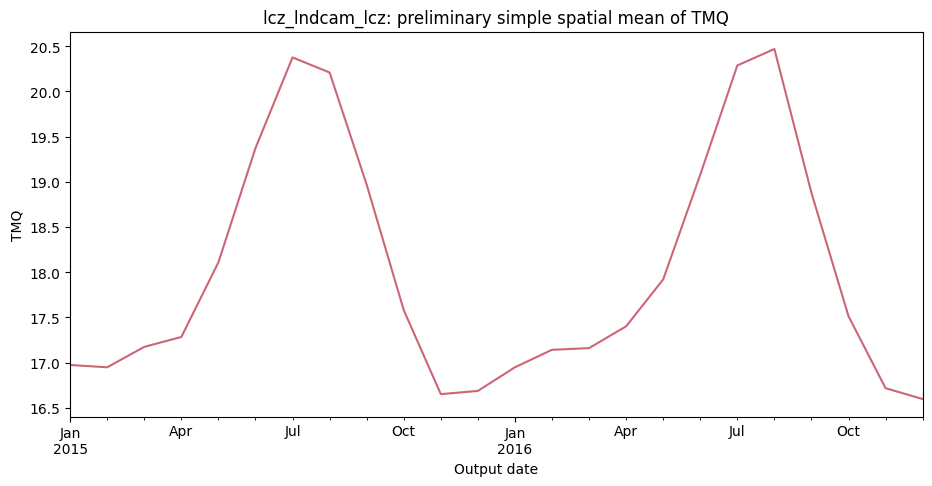

In [ ]:
# Choose a monthly CAM stream and a variable present in it; start with a small test.
PATTERN, VARIABLE, MAX_FILES = '*.cam.h0a.*.nc', 'TMQ', 24
series_files = sorted(ATM.glob(PATTERN)); series_files = series_files if MAX_FILES is None else series_files[:MAX_FILES]

# Open each file, calculate one scalar mean, and close it immediately to save memory.
result = []
for number, file in enumerate(series_files, 1):
    with xr.open_dataset(file) as ds:
        if VARIABLE not in ds: raise KeyError(f'{VARIABLE} is not present in {file.name}')
        result.append({'date':file_date(file), 'simple spatial mean':float(ds[VARIABLE].mean(skipna=True).load())})
    if number % 24 == 0: print(f'Processed {number}/{len(series_files)} files')
time_series = pd.DataFrame(result).set_index('date').sort_index()
display(time_series.describe())
ax = time_series.plot(color='#CC6677', legend=False)
ax.set(title=f'{CASE}: preliminary simple spatial mean of {VARIABLE}', xlabel='Output date', ylabel=VARIABLE); plt.show()

# Close open example files after all exploration is complete.
atm_ds.close(); lnd_ds.close()

## 7. Inspect restart output

Restart directories store model state needed to continue the simulation. They are different from the history files normally used for analysis. This final check reports the available restart dates and number of files.

In [ ]:
# Count all files and NetCDF files in each archived restart directory.
restart = []
for folder in sorted(p for p in REST.iterdir() if p.is_dir()):
    contents = list(folder.iterdir())
    restart.append({'restart date':folder.name, 'files':len(contents), 'NetCDF files':sum(f.suffix=='.nc' for f in contents)})
display(pd.DataFrame(restart))

,restart date,files,NetCDF files
0,2020-01-01-00000,20,15
1,2025-01-01-00000,20,15
2,2030-01-01-00000,20,15
3,2035-01-01-00000,20,15
4,2040-01-01-00000,20,15
5,2045-01-01-00000,20,15
